# Import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_squared_log_error

# Neural net module
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Read in the data


In [3]:
df = pd.read_csv('/content/drive/MyDrive/house-price-prediction/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Data Preprocessing and cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [6]:
# drop rows with missing values
df.dropna(axis=0, inplace=True)

In [7]:
df.shape

(20433, 10)

In [8]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


In [9]:
df['ocean_proximity'] = df['ocean_proximity'].map({"<1H OCEAN":0,"INLAND":1,"NEAR OCEAN":2,"NEAR BAY":3,"ISLAND":4})

In [10]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


# Handling Outliers

Outlier dapat memperburuk performa model regresi. Kita gunakan dua strategi:
1. **IQR Clipping** pada fitur numerik
2. **Log Transform** pada target `median_house_value` untuk mengurangi skewness

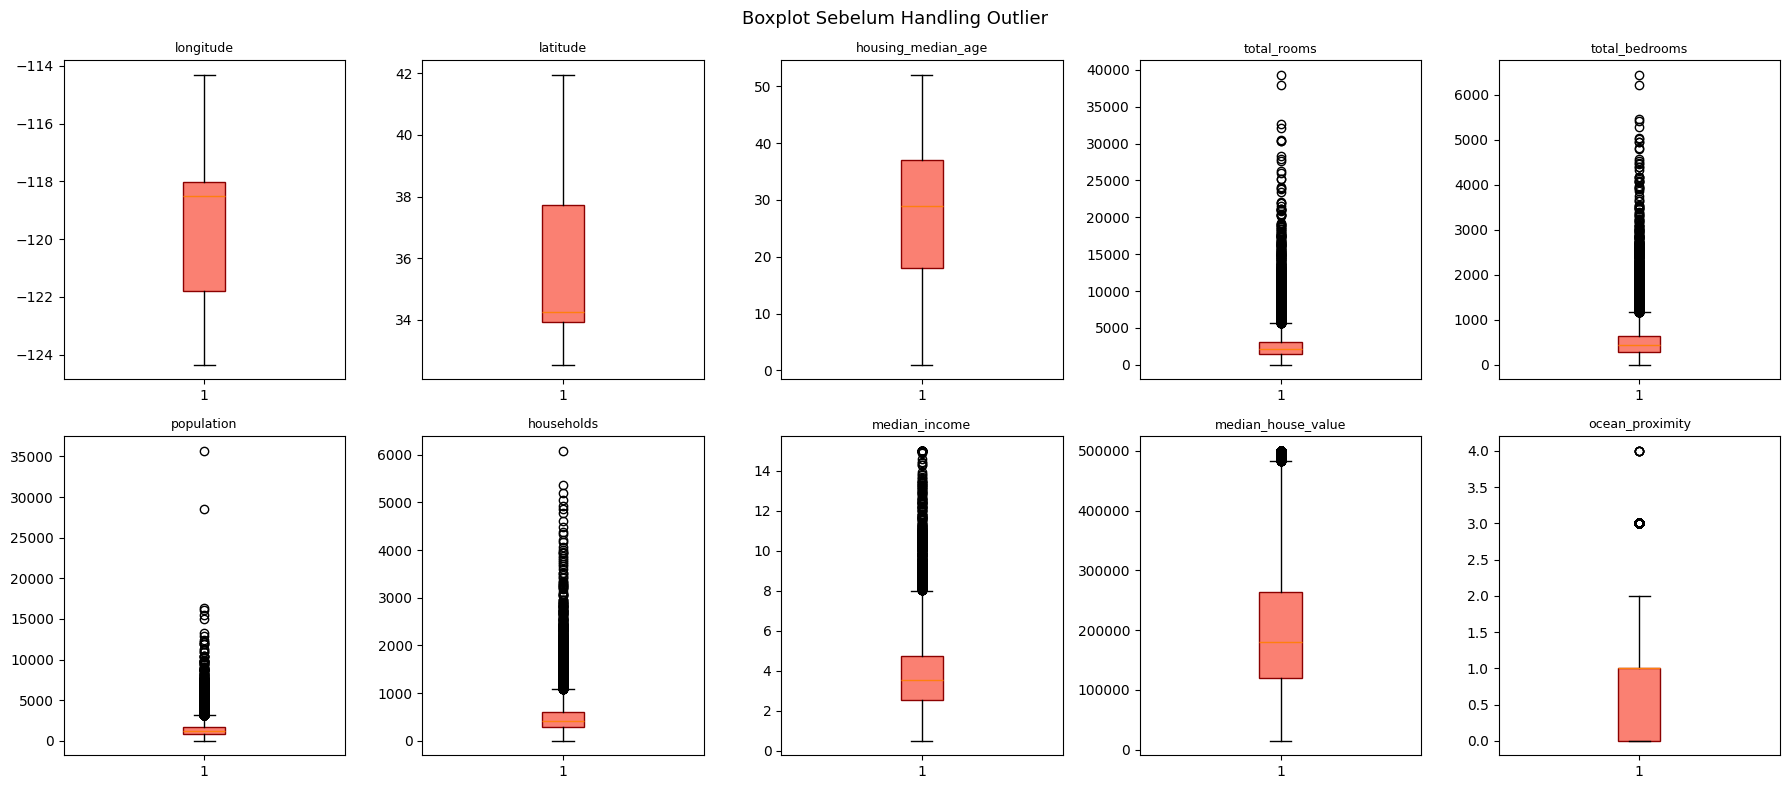

Shape sebelum: (20433, 10)


In [11]:
# ── Visualize outliers BEFORE handling ──────────────────────────────────────
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='salmon', color='darkred'))
    axes[i].set_title(f'{col}', fontsize=9)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot Sebelum Handling Outlier', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Shape sebelum: {df.shape}")

In [12]:
# ── IQR Clipping pada fitur (kecuali target) ────────────────────────────────
feature_cols = [c for c in numerical_cols if c != 'median_house_value']

df_clean = df.copy()
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print(f"Shape setelah IQR clipping: {df_clean.shape}")

Shape setelah IQR clipping: (20433, 10)


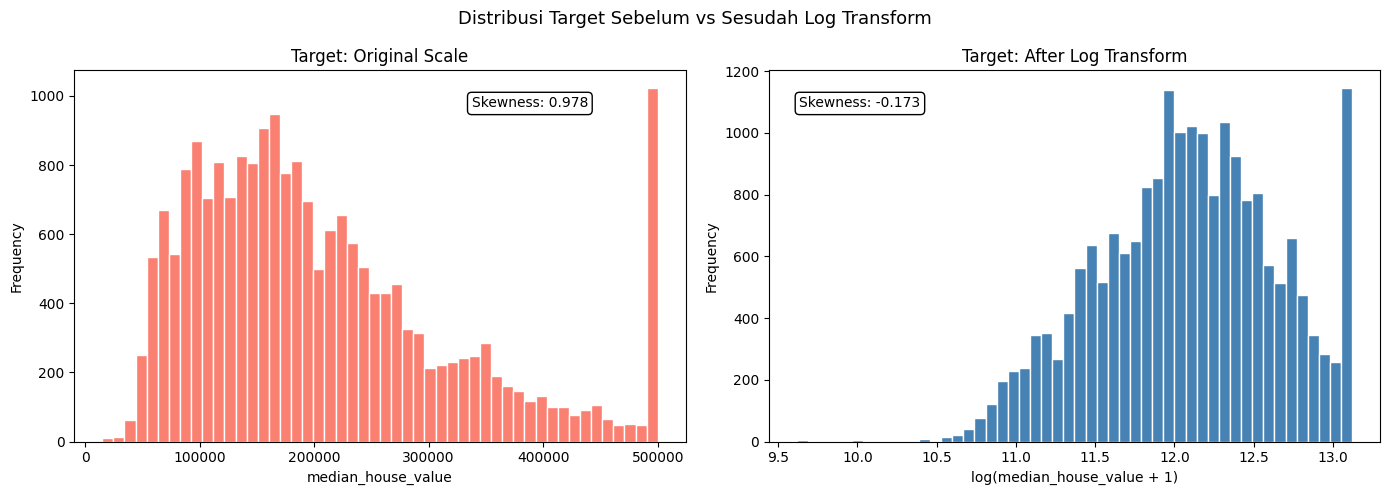

Skewness sebelum log transform : 0.9783
Skewness setelah log transform : -0.1726


In [13]:
# ── Log Transform pada target ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['median_house_value'], bins=50, color='salmon', edgecolor='white')
axes[0].set_title('Target: Original Scale')
axes[0].set_xlabel('median_house_value')
axes[0].set_ylabel('Frequency')
skew_before = df_clean['median_house_value'].skew()
axes[0].annotate(f'Skewness: {skew_before:.3f}', xy=(0.65, 0.9),
                 xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', fc='white'))

df_clean['median_house_value'] = np.log1p(df_clean['median_house_value'])

axes[1].hist(df_clean['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Target: After Log Transform')
axes[1].set_xlabel('log(median_house_value + 1)')
axes[1].set_ylabel('Frequency')
skew_after = df_clean['median_house_value'].skew()
axes[1].annotate(f'Skewness: {skew_after:.3f}', xy=(0.05, 0.9),
                 xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', fc='white'))

plt.suptitle('Distribusi Target Sebelum vs Sesudah Log Transform', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Skewness sebelum log transform : {skew_before:.4f}")
print(f"Skewness setelah log transform : {skew_after:.4f}")

# Feature Engineering

Fitur mentah seperti `total_rooms` kurang bermakna tanpa konteks. Kita buat fitur baru yang lebih informatif dengan memanfaatkan relasi antar kolom.

In [14]:
# ── Create derived features ──────────────────────────────────────────────────
df_clean['rooms_per_household']      = df_clean['total_rooms']    / df_clean['households']
df_clean['bedrooms_per_room']        = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['population_per_household'] = df_clean['population']     / df_clean['households']

print("Fitur baru yang ditambahkan:")
print(df_clean[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe())
print(f"\nShape setelah feature engineering: {df_clean.shape}")

Fitur baru yang ditambahkan:
       rooms_per_household  bedrooms_per_room  population_per_household
count         20433.000000       20433.000000              20433.000000
mean              5.396964           0.212989                  3.000776
std               2.412481           0.055892                  5.214395
min               0.846154           0.100000                  0.692308
25%               4.487805           0.177866                  2.451524
50%               5.213303           0.206475                  2.849138
75%               5.960967           0.237095                  3.247312
max             141.909091           1.000000                520.750000

Shape setelah feature engineering: (20433, 13)


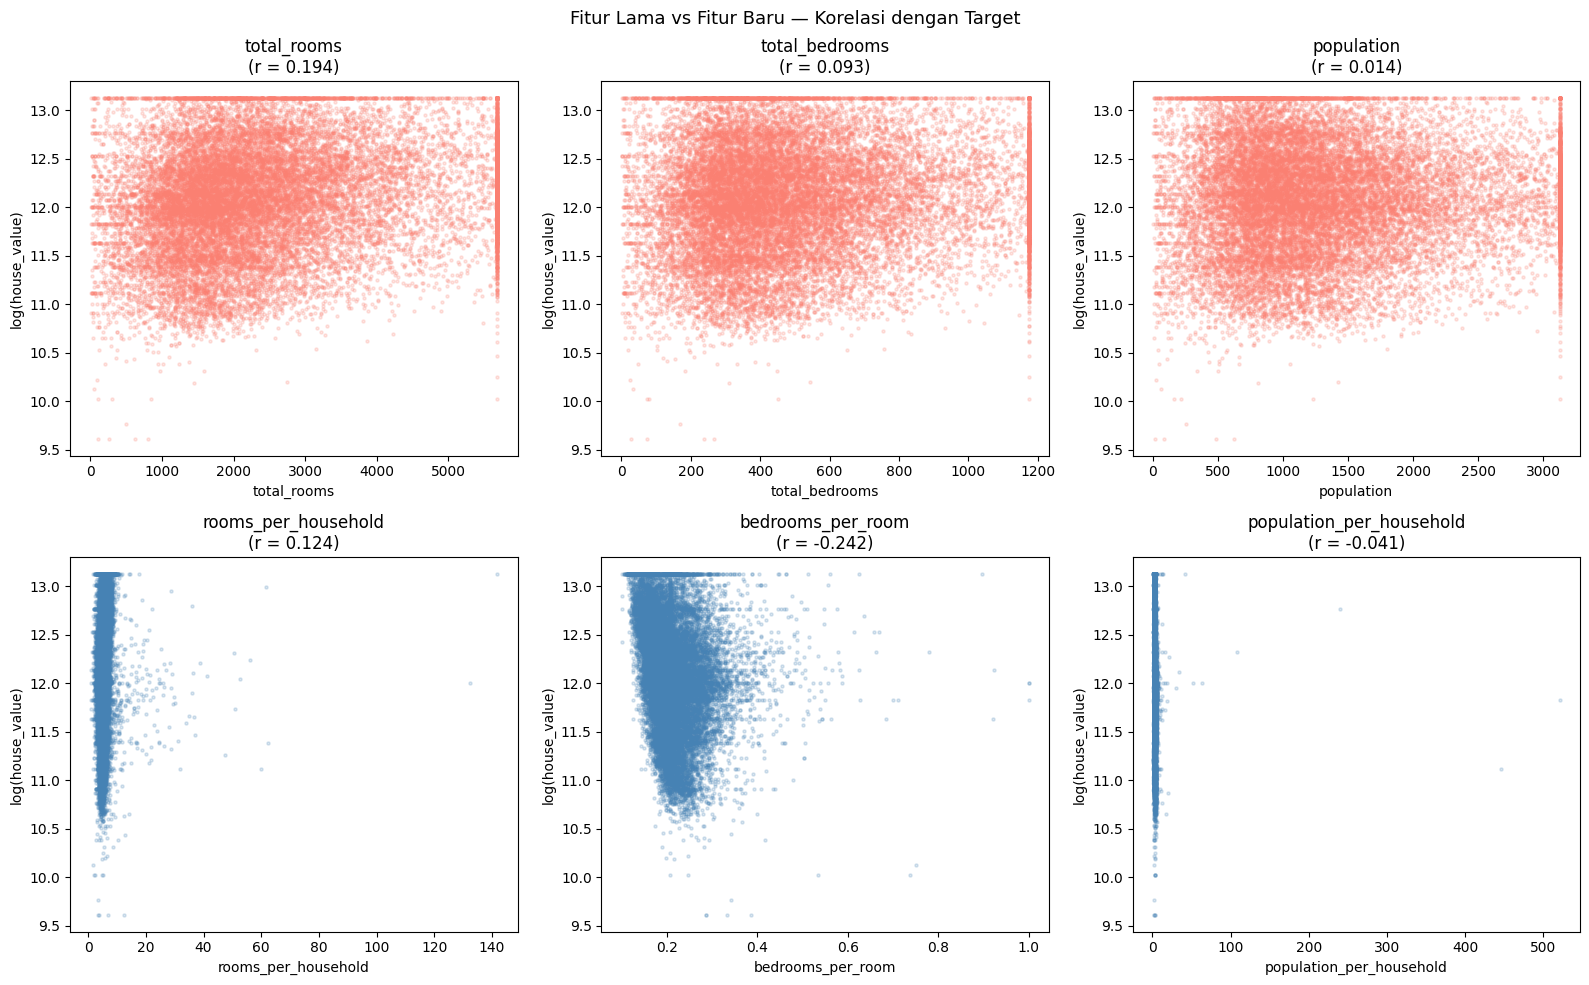

In [15]:
# ── Korelasi fitur baru dengan target ────────────────────────────────────────
new_features = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
old_features = ['total_rooms', 'total_bedrooms', 'population']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, (new_f, old_f) in enumerate(zip(new_features, old_features)):
    # Old feature
    axes[0][i].scatter(df_clean[old_f], df_clean['median_house_value'],
                       alpha=0.2, s=5, color='salmon')
    corr_old = df_clean[old_f].corr(df_clean['median_house_value'])
    axes[0][i].set_title(f'{old_f}\n(r = {corr_old:.3f})')
    axes[0][i].set_xlabel(old_f)
    axes[0][i].set_ylabel('log(house_value)')

    # New feature
    axes[1][i].scatter(df_clean[new_f], df_clean['median_house_value'],
                       alpha=0.2, s=5, color='steelblue')
    corr_new = df_clean[new_f].corr(df_clean['median_house_value'])
    axes[1][i].set_title(f'{new_f}\n(r = {corr_new:.3f})')
    axes[1][i].set_xlabel(new_f)
    axes[1][i].set_ylabel('log(house_value)')

plt.suptitle('Fitur Lama vs Fitur Baru — Korelasi dengan Target', fontsize=13)
plt.tight_layout()
plt.show()

# Exploratory Data Analysis (EDA)

In [16]:
# Dataset overview
print(f"Shape: {df_clean.shape}")
print(f"\nData Types:\n{df_clean.dtypes}")
print(f"\nBasic Statistics:")
df_clean.describe()

Shape: (20433, 13)

Data Types:
longitude                   float64
latitude                    float64
housing_median_age          float64
total_rooms                 float64
total_bedrooms              float64
population                  float64
households                  float64
median_income               float64
median_house_value          float64
ocean_proximity             float64
rooms_per_household         float64
bedrooms_per_room           float64
population_per_household    float64
dtype: object

Basic Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
count,20433.000000,20433.000000,20433.000000,20433.00000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2440.46557,502.538076,1335.894240,468.742426,3.801660,12.084869,0.853497,5.396964,0.212989,3.000776
std,2.003578,2.136348,12.591805,1394.61925,287.085265,763.964234,264.981678,1.657657,0.569218,0.894334,2.412481,0.055892,5.214395
min,-124.350000,32.540000,1.000000,2.00000,1.000000,3.000000,1.000000,0.499900,9.615805,0.000000,0.846154,0.100000,0.692308
25%,-121.800000,33.930000,18.000000,1450.00000,296.000000,787.000000,280.000000,2.563700,11.691080,0.000000,4.487805,0.177866,2.451524
50%,-118.490000,34.260000,29.000000,2127.00000,435.000000,1166.000000,409.000000,3.536500,12.099050,1.000000,5.213303,0.206475,2.849138
75%,-118.010000,37.720000,37.000000,3143.00000,647.000000,1722.000000,604.000000,4.744000,12.486356,1.000000,5.960967,0.237095,3.247312
max,-114.310000,41.950000,52.000000,5682.50000,1173.500000,3124.500000,1090.000000,8.014450,13.122367,2.500000,141.909091,1.000000,520.750000


In [17]:
# Missing value visualization
plt.figure(figsize=(10, 4))
missing = df_clean.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    sns.barplot(x=missing.index, y=missing.values, palette='viridis')
    plt.title('Missing Values per Column')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print(f"Total missing values:\n{missing}")
else:
    print("No missing values found.")

No missing values found.


<Figure size 1000x400 with 0 Axes>

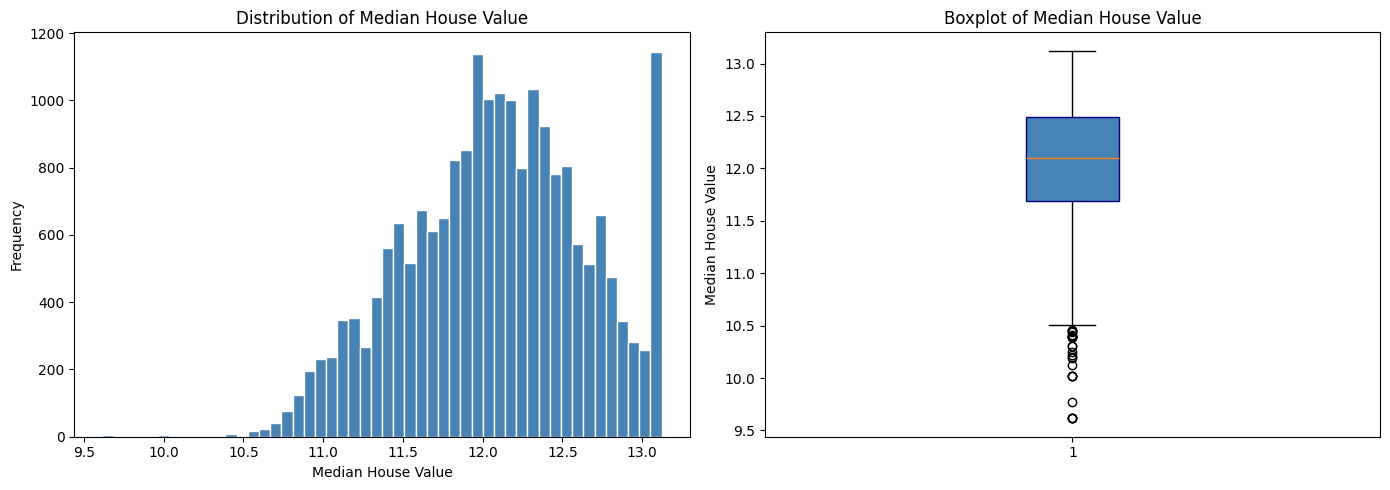

Skewness: -0.1726
Kurtosis: -0.4260


In [18]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df_clean['median_house_value'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Median House Value')
axes[1].set_ylabel('Median House Value')

plt.tight_layout()
plt.show()
print(f"Skewness: {df_clean['median_house_value'].skew():.4f}")
print(f"Kurtosis: {df_clean['median_house_value'].kurtosis():.4f}")

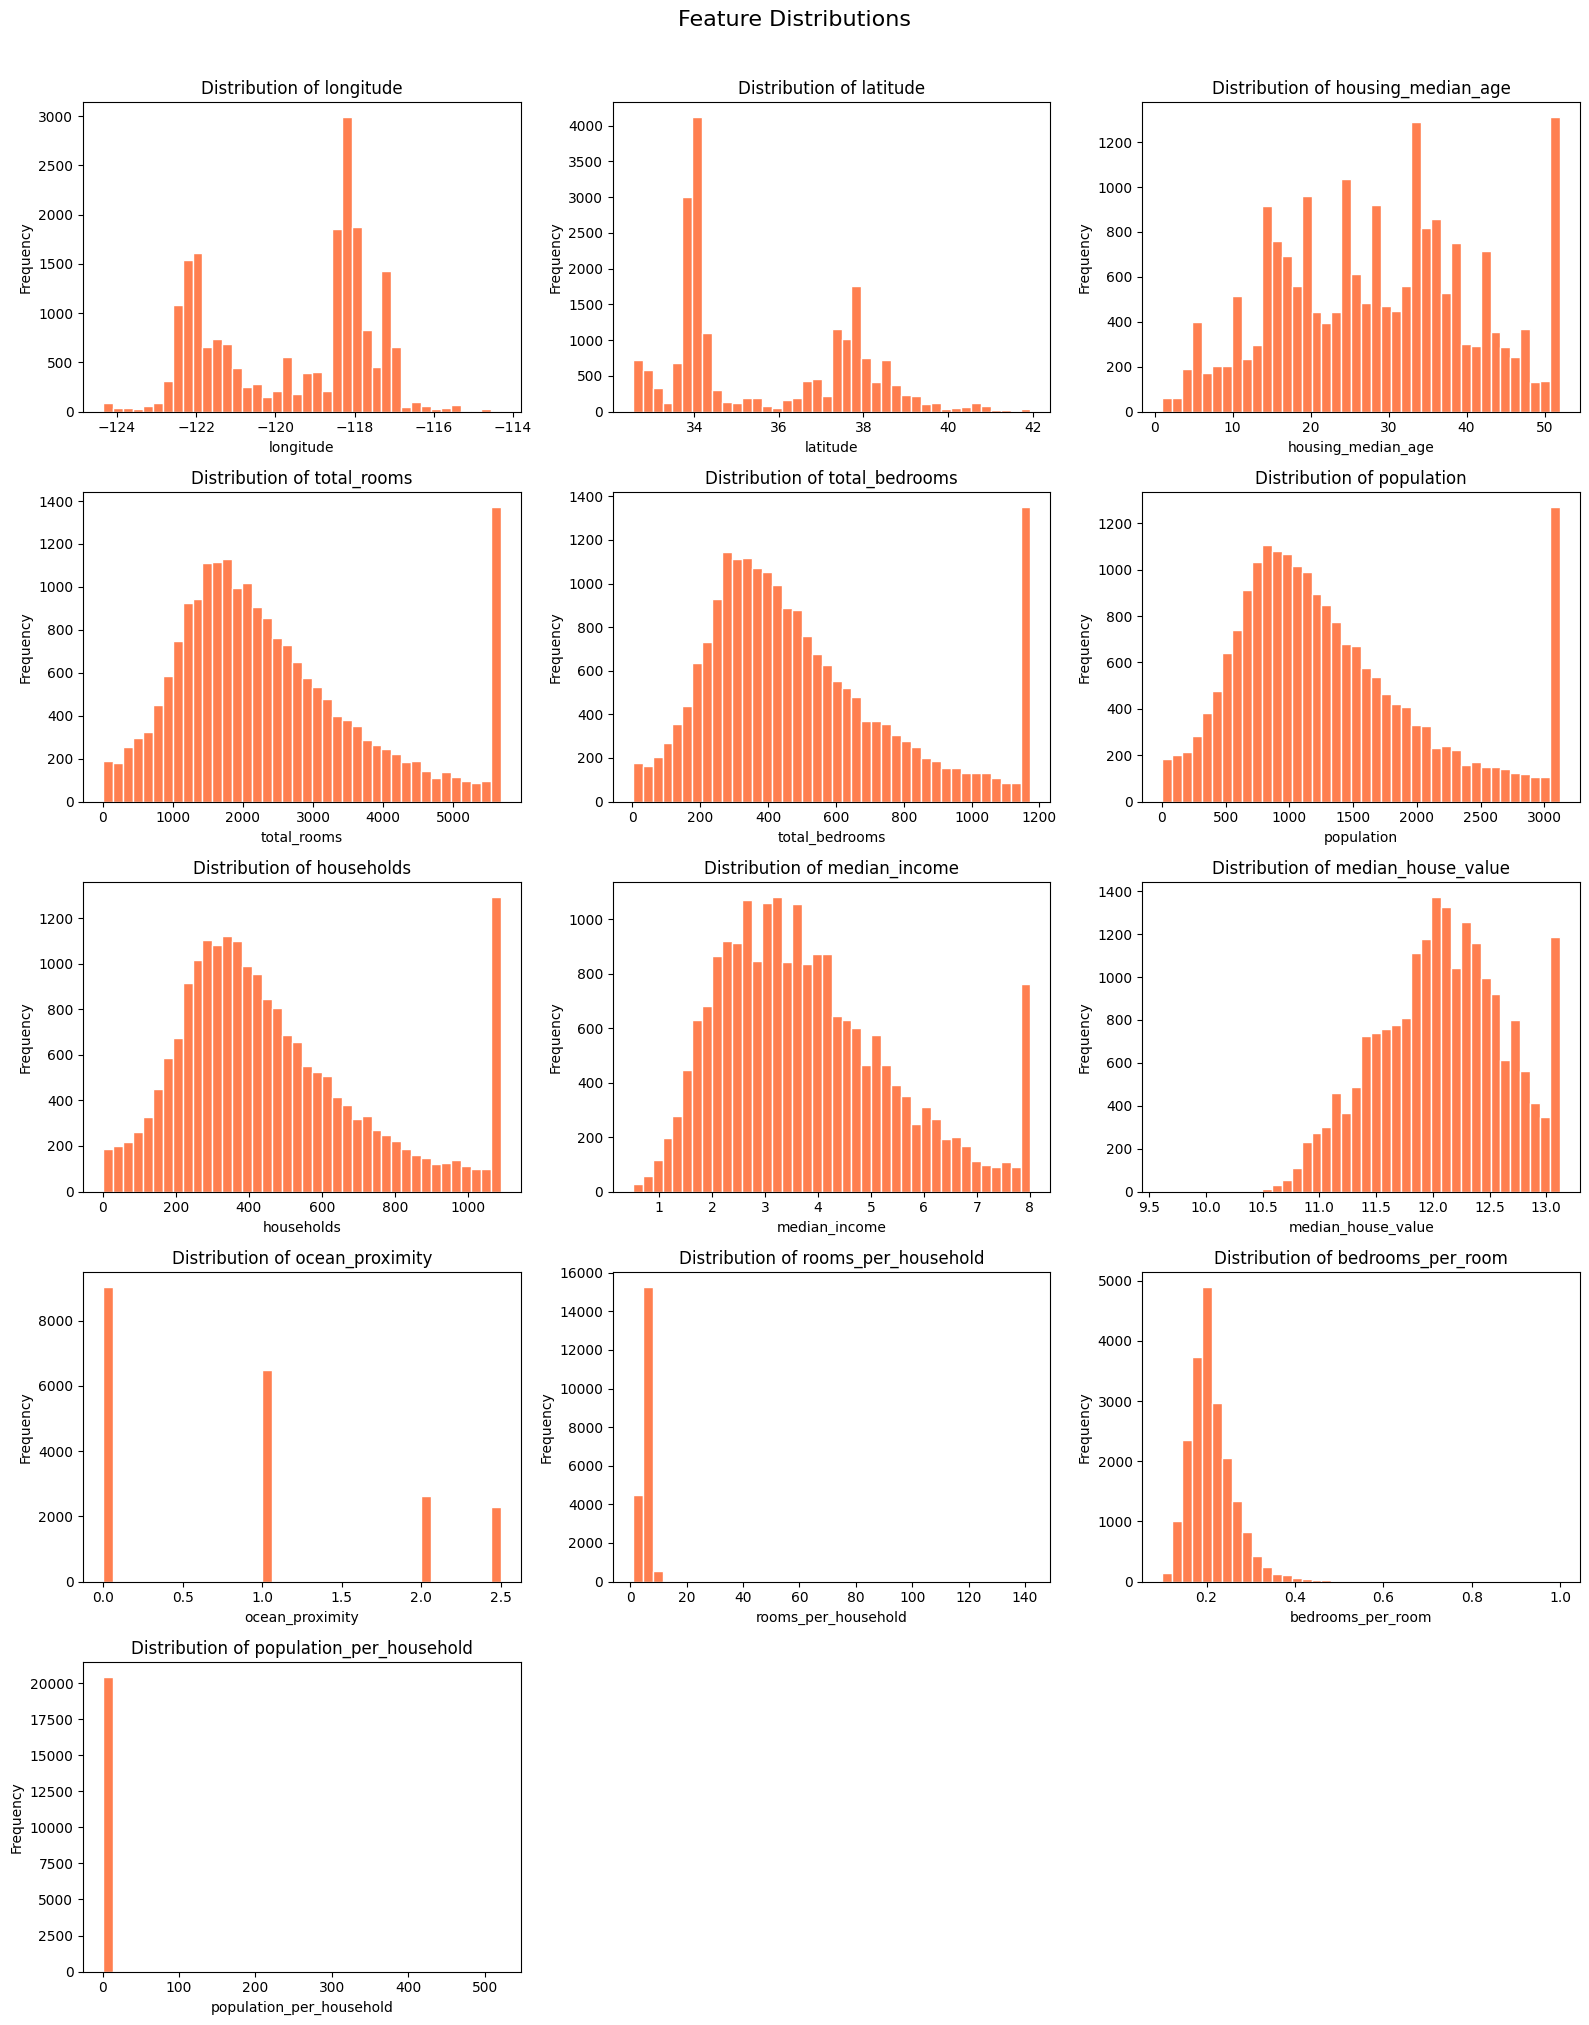

In [19]:
# Distribution of all numerical features
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df_clean[col], bins=40, color='coral', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

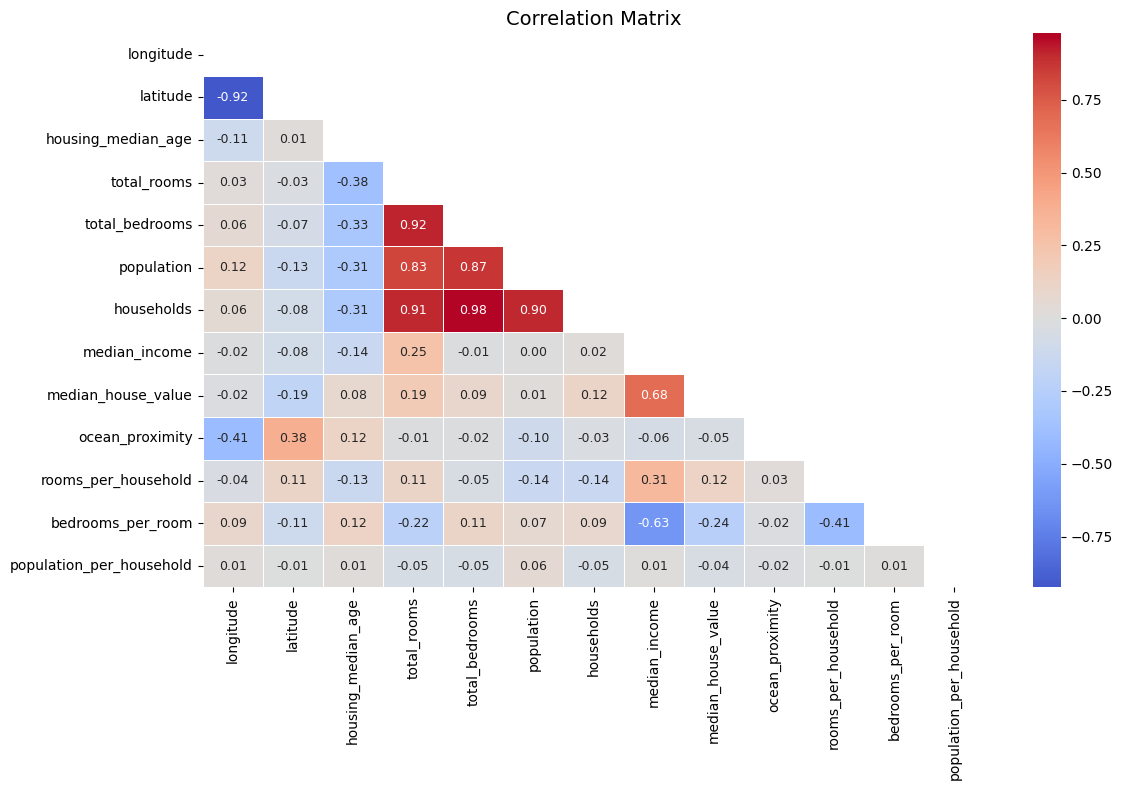


Correlation with median_house_value:
median_house_value          1.000000
median_income               0.682226
total_rooms                 0.194152
rooms_per_household         0.123616
households                  0.115259
total_bedrooms              0.092988
housing_median_age          0.076550
population                  0.014086
longitude                  -0.022855
population_per_household   -0.041088
ocean_proximity            -0.045104
latitude                   -0.192770
bedrooms_per_room          -0.242054
Name: median_house_value, dtype: float64


In [20]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with target
print("\nCorrelation with median_house_value:")
print(corr_matrix['median_house_value'].sort_values(ascending=False))

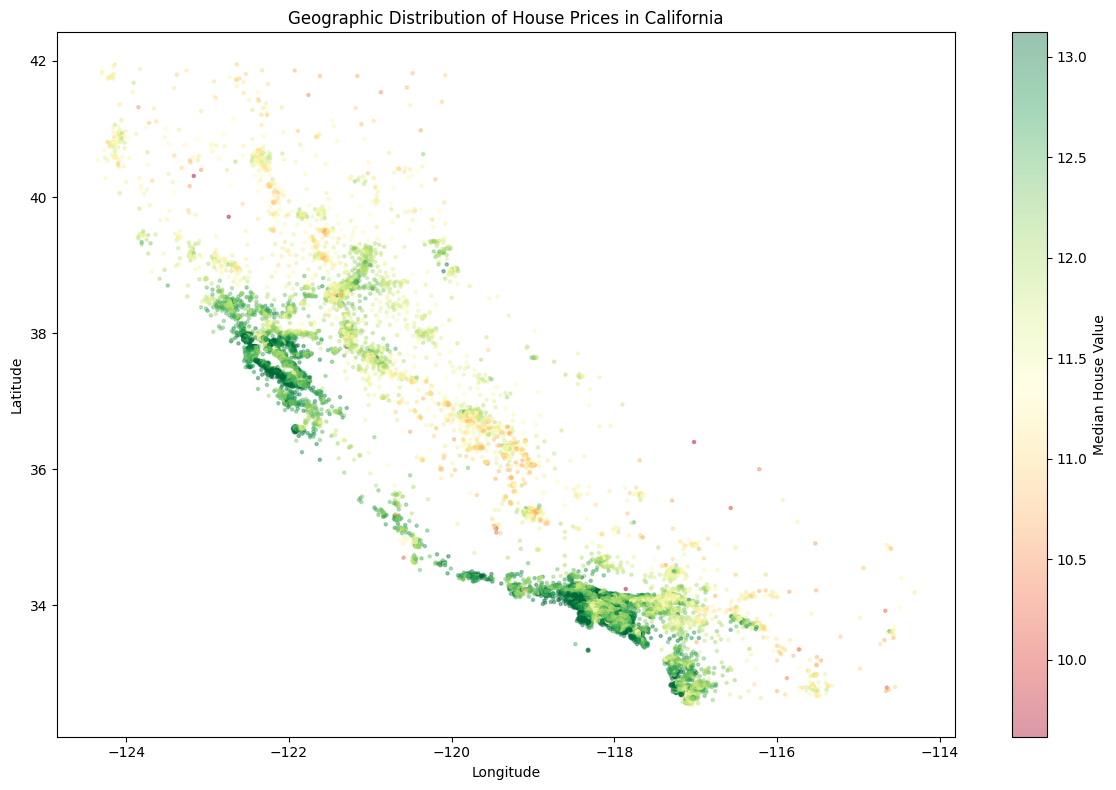

In [21]:
# Geographic distribution of house prices
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_clean['longitude'], df_clean['latitude'],
                      c=df_clean['median_house_value'], cmap='RdYlGn',
                      alpha=0.4, s=5)
plt.colorbar(scatter, label='Median House Value')
plt.title('Geographic Distribution of House Prices in California')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

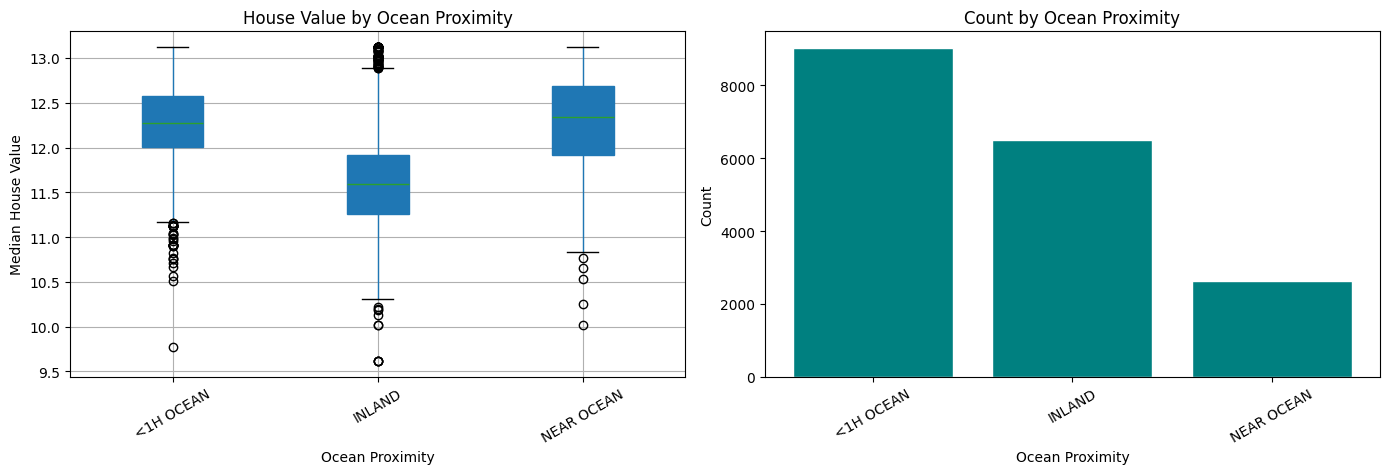

In [22]:
# House value by ocean proximity
ocean_map_rev = {0: "<1H OCEAN", 1: "INLAND", 2: "NEAR OCEAN", 3: "NEAR BAY", 4: "ISLAND"}
df_eda = df_clean.copy()
df_eda['ocean_label'] = df_eda['ocean_proximity'].map(ocean_map_rev)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df_eda.boxplot(column='median_house_value', by='ocean_label',
               ax=axes[0], patch_artist=True)
axes[0].set_title('House Value by Ocean Proximity')
axes[0].set_xlabel('Ocean Proximity')
axes[0].set_ylabel('Median House Value')
plt.sca(axes[0])
plt.xticks(rotation=30)

# Count plot
counts = df_eda['ocean_label'].value_counts()
axes[1].bar(counts.index, counts.values, color='teal', edgecolor='white')
axes[1].set_title('Count by Ocean Proximity')
axes[1].set_xlabel('Ocean Proximity')
axes[1].set_ylabel('Count')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('')
plt.tight_layout()
plt.show()

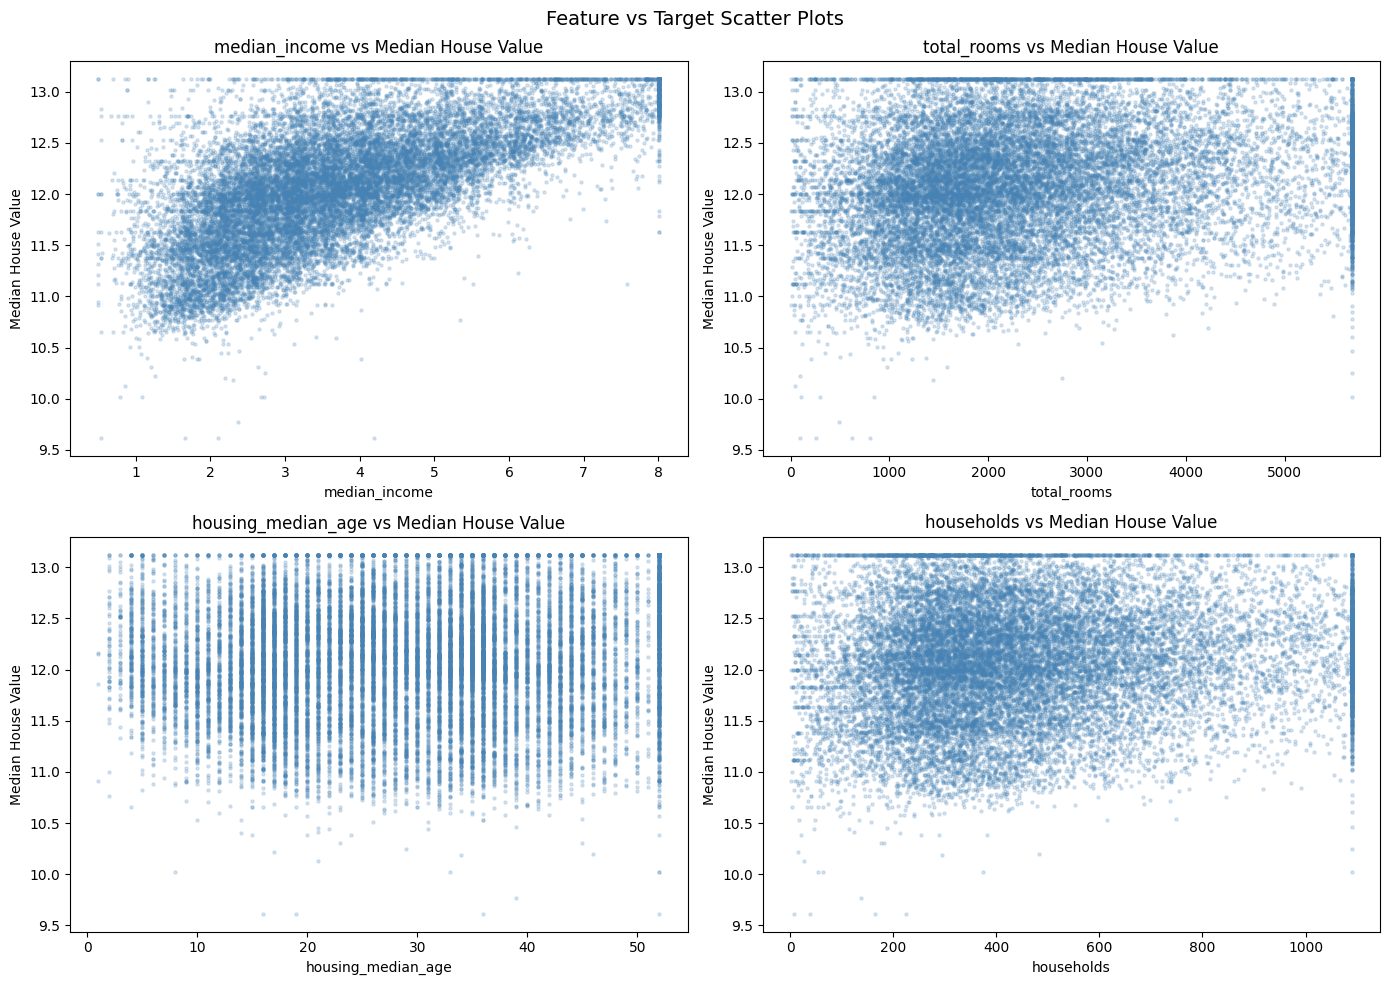

In [23]:
# Scatter plots: top features vs target
top_features = ['median_income', 'total_rooms', 'housing_median_age', 'households']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df_clean[feat], df_clean['median_house_value'],
                    alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Median House Value')
    axes[i].set_title(f'{feat} vs Median House Value')

plt.suptitle('Feature vs Target Scatter Plots', fontsize=14)
plt.tight_layout()
plt.show()

# Train test split

In [24]:
# Target variable is 'median_house_value' (log-transformed)
# Note: df_clean now has outliers clipped and engineered features
y = df_clean['median_house_value']
x = df_clean.drop('median_house_value', axis=1)
print("Features used:", list(x.columns))
print(x.shape)
print(y.shape)

Features used: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
(20433, 12)
(20433,)


In [25]:
# convert to numpy array
x = np.array(x)
y = np.array(y)

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(16346, 12)
(4087, 12)
(16346,)
(4087,)


# Scaling

In [27]:
# Use MinMax scaler
min_max_scaler = MinMaxScaler()
x_train = min_max_scaler.fit_transform(x_train)
x_test = min_max_scaler.transform(x_test)

In [28]:
print(x_train)
print(x_test)

[[0.54425229 0.30180659 0.66666667 ... 0.0351414  0.08308308 0.00333933]
 [0.30315361 0.58448459 0.56862745 ... 0.03217204 0.08522981 0.00580475]
 [0.6948118  0.16790648 0.09803922 ... 0.02990086 0.1183458  0.0041807 ]
 ...
 [0.23601221 0.51328374 0.68627451 ... 0.02830134 0.12039841 0.00483822]
 [0.19226857 0.55366631 1.         ... 0.02909486 0.13260512 0.00614256]
 [0.51068159 0.19978746 0.43137255 ... 0.03674491 0.08204446 0.00415057]]
[[0.71922686 0.02231668 0.43137255 ... 0.02165945 0.18932597 0.0027823 ]
 [0.30620549 0.64718385 0.45098039 ... 0.03469696 0.09305749 0.00373851]
 [0.3387589  0.54091392 0.74509804 ... 0.02058651 0.17467043 0.00517474]
 ...
 [0.15055951 0.62274176 0.76470588 ... 0.03298501 0.08423386 0.00342629]
 [0.6103764  0.17534538 1.         ... 0.03905934 0.06950965 0.00414381]
 [0.72227874 0.08926674 0.25490196 ... 0.04014496 0.05806957 0.00424747]]


In [29]:
x_train.shape[1]

12

# Baseline Model Comparison

Sebelum melatih ANN, kita bandingkan dengan dua model baseline: **Linear Regression** dan **Random Forest**. Ini penting untuk mengetahui apakah kompleksitas ANN benar-benar memberikan nilai tambah.

In [30]:
# ── Linear Regression ────────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("── Linear Regression ──────────────────────")
print(f"  MAE   : {mae_lr:.4f}")
print(f"  MSE   : {mse_lr:.4f}")
print(f"  R²    : {r2_lr:.4f}")

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("\n── Random Forest ──────────────────────────")
print(f"  MAE   : {mae_rf:.4f}")
print(f"  MSE   : {mse_rf:.4f}")
print(f"  R²    : {r2_rf:.4f}")

── Linear Regression ──────────────────────
  MAE   : 0.2343
  MSE   : 0.0974
  R²    : 0.6882

── Random Forest ──────────────────────────
  MAE   : 0.1603
  MSE   : 0.0549
  R²    : 0.8243


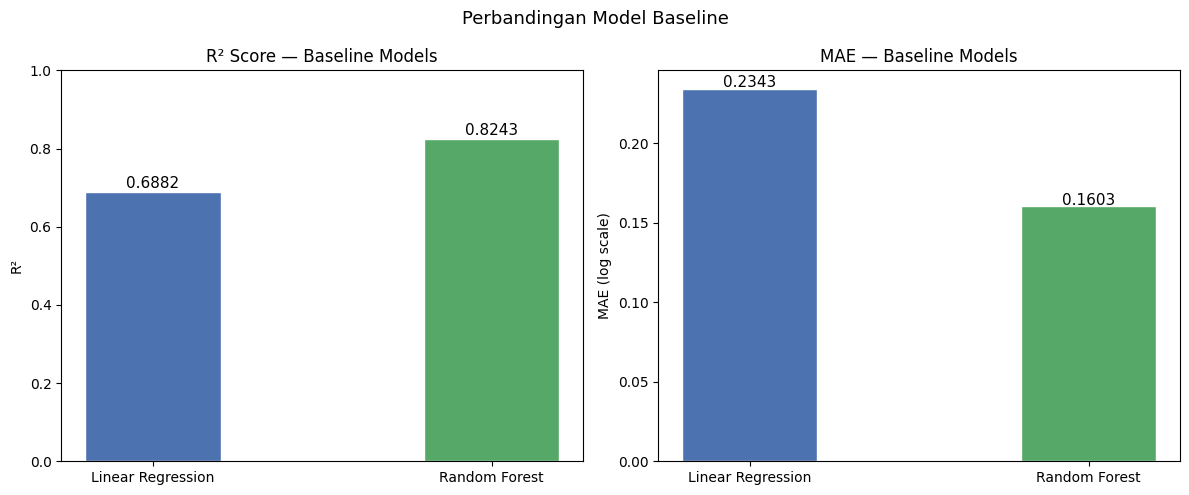


Target: ANN harus melampaui skor ini!


In [31]:
# ── Visualize baseline comparison ────────────────────────────────────────────
models_names = ['Linear Regression', 'Random Forest']
r2_scores    = [r2_lr, r2_rf]
mae_scores   = [mae_lr, mae_rf]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C72B0', '#55A868']

axes[0].bar(models_names, r2_scores, color=colors, edgecolor='white', width=0.4)
axes[0].set_title('R² Score — Baseline Models')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)

axes[1].bar(models_names, mae_scores, color=colors, edgecolor='white', width=0.4)
axes[1].set_title('MAE — Baseline Models')
axes[1].set_ylabel('MAE (log scale)')
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=11)

plt.suptitle('Perbandingan Model Baseline', fontsize=13)
plt.tight_layout()
plt.show()
print("\nTarget: ANN harus melampaui skor ini!")

# Hyperparameter Tuning

Kita coba beberapa konfigurasi arsitektur untuk menemukan yang terbaik, daripada memilih layer size secara arbitrer.

In [32]:
# ── Define architectures to try ──────────────────────────────────────────────
architectures = {
    'Small  (64-32)'     : [64,  32],
    'Medium (128-64-32)' : [128, 64, 32],
    'Large  (256-128-64)': [256, 128, 64],
}

def build_model(layer_sizes, input_dim):
    model = Sequential()
    model.add(Dense(layer_sizes[0], input_shape=(input_dim,), activation='relu'))
    model.add(Dropout(0.2))
    for size in layer_sizes[1:]:
        model.add(Dense(size, activation='relu'))
        model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

tuning_results = {}
es = EarlyStopping(monitor='val_loss', mode='min', patience=15, restore_best_weights=True)

for name, layers in architectures.items():
    print(f"Training: {name} ...")
    m = build_model(layers, x_train.shape[1])
    hist = m.fit(x_train, y_train,
                 validation_data=(x_test, y_test),
                 callbacks=[es], epochs=100, batch_size=64,
                 verbose=0)
    y_p = m.predict(x_test, verbose=0)
    r2  = r2_score(y_test, y_p)
    mae = mean_absolute_error(y_test, y_p)
    tuning_results[name] = {'model': m, 'history': hist, 'r2': r2, 'mae': mae}
    print(f"  → R²: {r2:.4f}  |  MAE: {mae:.4f}")

best_name = max(tuning_results, key=lambda k: tuning_results[k]['r2'])
print(f"\n✅ Best architecture: {best_name}  (R² = {tuning_results[best_name]['r2']:.4f})")

Training: Small  (64-32) ...
  → R²: 0.7550  |  MAE: 0.2025
Training: Medium (128-64-32) ...
  → R²: -1.5820  |  MAE: 0.7383
Training: Large  (256-128-64) ...
  → R²: -0.2935  |  MAE: 0.4877

✅ Best architecture: Small  (64-32)  (R² = 0.7550)


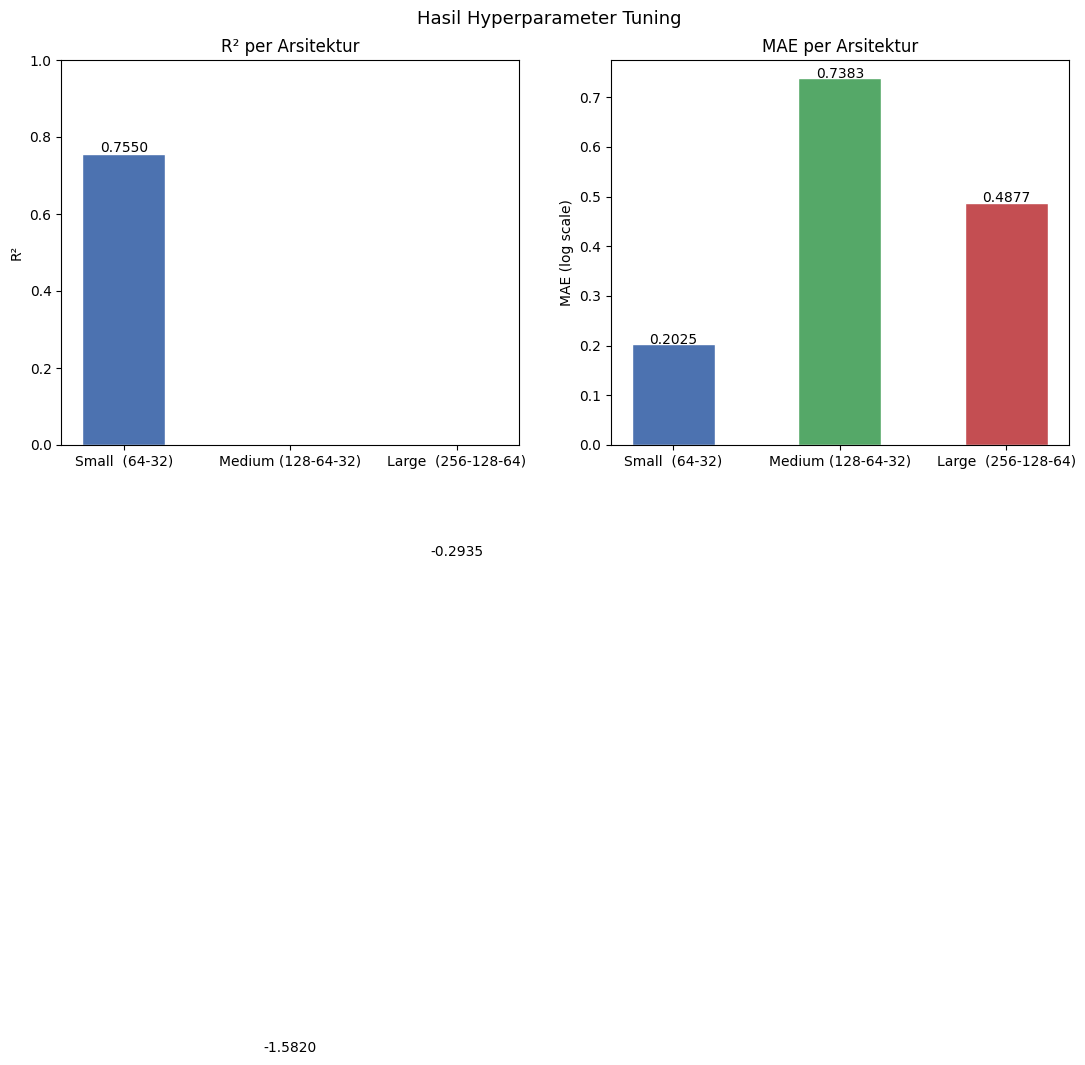

In [33]:
# ── Plot tuning results ──────────────────────────────────────────────────────
names  = list(tuning_results.keys())
r2s    = [tuning_results[k]['r2']  for k in names]
maes   = [tuning_results[k]['mae'] for k in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = ['#4C72B0', '#55A868', '#C44E52']

axes[0].bar(names, r2s, color=palette, edgecolor='white', width=0.5)
axes[0].set_title('R² per Arsitektur')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2s):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(names, maes, color=palette, edgecolor='white', width=0.5)
axes[1].set_title('MAE per Arsitektur')
axes[1].set_ylabel('MAE (log scale)')
for i, v in enumerate(maes):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Hasil Hyperparameter Tuning', fontsize=13)
plt.tight_layout()
plt.show()

# Cross-Validation

Train-test split tunggal rentan terhadap variasi data. K-Fold CV (k=5) memberikan estimasi performa yang lebih stabil dan tidak bias.

In [34]:
# ── 5-Fold Cross-Validation pada arsitektur terbaik ─────────────────────────
best_layers = architectures[best_name]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

x_full = np.concatenate([x_train, x_test], axis=0)
y_full = np.concatenate([y_train, y_test], axis=0)

cv_r2_scores  = []
cv_mae_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(x_full)):
    x_tr, x_val = x_full[train_idx], x_full[val_idx]
    y_tr, y_val = y_full[train_idx], y_full[val_idx]

    m_cv = build_model(best_layers, x_tr.shape[1])
    es_cv = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    m_cv.fit(x_tr, y_tr, validation_data=(x_val, y_val),
             callbacks=[es_cv], epochs=100, batch_size=64, verbose=0)

    y_cv_pred = m_cv.predict(x_val, verbose=0)
    cv_r2_scores.append(r2_score(y_val, y_cv_pred))
    cv_mae_scores.append(mean_absolute_error(y_val, y_cv_pred))
    print(f"Fold {fold+1} → R²: {cv_r2_scores[-1]:.4f}  |  MAE: {cv_mae_scores[-1]:.4f}")

print(f"\n── Cross-Validation Summary ────────────────────")
print(f"  R²  : {np.mean(cv_r2_scores):.4f}  ±  {np.std(cv_r2_scores):.4f}")
print(f"  MAE : {np.mean(cv_mae_scores):.4f}  ±  {np.std(cv_mae_scores):.4f}")

Fold 1 → R²: 0.7027  |  MAE: 0.2349
Fold 2 → R²: 0.7559  |  MAE: 0.2042
Fold 3 → R²: 0.7798  |  MAE: 0.1990
Fold 4 → R²: 0.7606  |  MAE: 0.2034
Fold 5 → R²: 0.7550  |  MAE: 0.2071

── Cross-Validation Summary ────────────────────
  R²  : 0.7508  ±  0.0257
  MAE : 0.2097  ±  0.0128


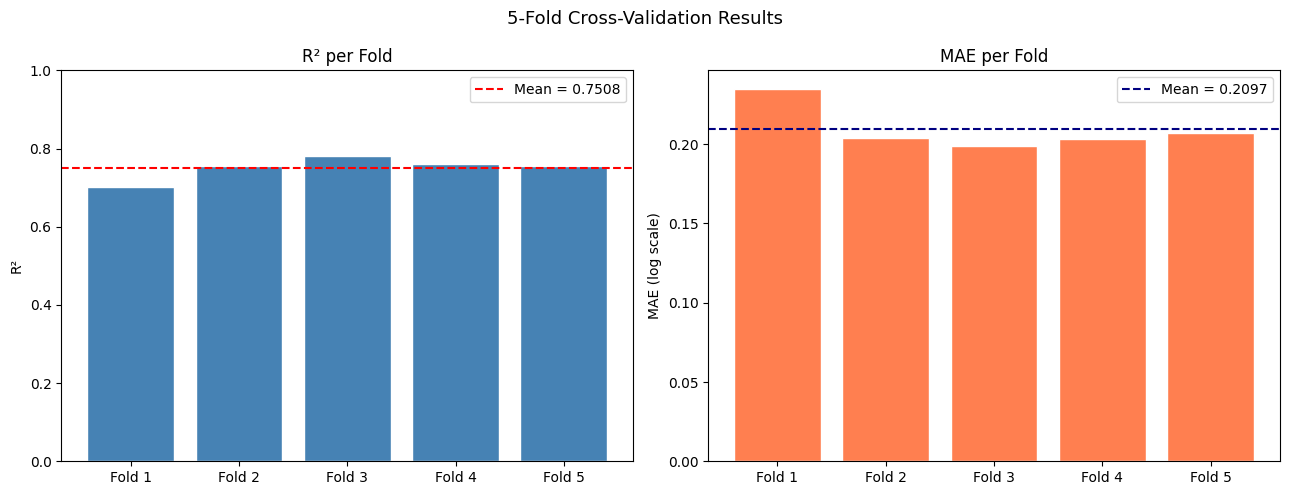

In [35]:
# ── Visualize CV scores ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
folds = [f'Fold {i+1}' for i in range(5)]

axes[0].bar(folds, cv_r2_scores, color='steelblue', edgecolor='white')
axes[0].axhline(np.mean(cv_r2_scores), color='red', linestyle='--',
                label=f'Mean = {np.mean(cv_r2_scores):.4f}')
axes[0].set_title('R² per Fold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(folds, cv_mae_scores, color='coral', edgecolor='white')
axes[1].axhline(np.mean(cv_mae_scores), color='navy', linestyle='--',
                label=f'Mean = {np.mean(cv_mae_scores):.4f}')
axes[1].set_title('MAE per Fold')
axes[1].set_ylabel('MAE (log scale)')
axes[1].legend()

plt.suptitle('5-Fold Cross-Validation Results', fontsize=13)
plt.tight_layout()
plt.show()

# Building  model (ANN)

In [36]:
model = Sequential([
    #input layer
    Dense(1000, input_shape=(x_train.shape[1],), activation='relu'),
    Dropout(0.2),
    #two hidden layers
    Dense(500, activation='relu'),
    Dropout(0.2),
    Dense(250, activation='relu'),
    #output layer
    Dense(1,activation='linear') # here 1 shows countinuous value(regression)
])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 1000)           │        13,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 639,001 (2.44 MB)

 Trainable params: 639,001 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

Total Parameters: The "Total params" section indicates that the model has a total of 636,001 parameters. These are the weights and biases that the model will learn during training.

Trainable Parameters: The "Trainable params" section shows that all 636,001 parameters in the model are trainable, meaning they will be updated and adjusted during training to optimize the model's performance.

Non-trainable Parameters: The "Non-trainable params" section is typically 0, which means there are no parameters that won't be updated during training.

In [37]:
# Compile the model and set easlystoping
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
es = EarlyStopping(monitor='val_loss',mode='min',patience=50, restore_best_weights=True)

In [38]:
# fit the model (training)
history = model.fit(x_train, y_train, validation_data= (x_test, y_test), callbacks=[es], epochs=10, batch_size=50, verbose=1)

Epoch 1/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 3.6647 - mae: 1.4392 - val_loss: 3.6033 - val_mae: 1.8297
Epoch 2/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 1.7367 - mae: 1.1080 - val_loss: 2.6495 - val_mae: 1.5694
Epoch 3/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 1.4014 - mae: 0.9741 - val_loss: 1.2796 - val_mae: 1.0421
Epoch 4/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 1.1896 - mae: 0.8980 - val_loss: 0.4517 - val_mae: 0.5814
Epoch 5/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 1.0472 - mae: 0.8426 - val_loss: 0.4119 - val_mae: 0.5430
Epoch 6/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.9393 - mae: 0.7934 - val_loss: 0.6932 - val_mae: 0.7630
Epoch 7/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.8149 - mae: 0.7374 - val_loss: 0.1556 - val_mae: 0.3077
Epoch 8/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.5929 - mae: 0.6255 - val_loss: 0.2647 - val_mae: 0.4436
Epoch 9/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/

# Analisis Residual

Analisis residual mengungkap apakah error model menyebar acak (ideal) atau memiliki pola tertentu (tanda model masih bisa diperbaiki).

In [39]:
# ── Use best model from tuning ───────────────────────────────────────────────
model = tuning_results[best_name]['model']
y_pred = model.predict(x_test, verbose=0).flatten()

residuals = y_test - y_pred

mae_ann  = mean_absolute_error(y_test, y_pred)
mse_ann  = mean_squared_error(y_test, y_pred)
r2_ann   = r2_score(y_test, y_pred)
rmse_ann = np.sqrt(mse_ann)

print("── ANN (Best Architecture) ─────────────────────")
print(f"  MAE  : {mae_ann:.4f}")
print(f"  RMSE : {rmse_ann:.4f}")
print(f"  R²   : {r2_ann:.4f}")
print(f"\n── Perbandingan Final ──────────────────────────")
print(f"  {'Model':<25} {'R²':>8}  {'MAE':>8}")
print(f"  {'-'*45}")
print(f"  {'Linear Regression':<25} {r2_lr:>8.4f}  {mae_lr:>8.4f}")
print(f"  {'Random Forest':<25} {r2_rf:>8.4f}  {mae_rf:>8.4f}")
print(f"  {f'ANN ({best_name})':<25} {r2_ann:>8.4f}  {mae_ann:>8.4f}")

── ANN (Best Architecture) ─────────────────────
  MAE  : 0.2025
  RMSE : 0.2766
  R²   : 0.7550

── Perbandingan Final ──────────────────────────
  Model                           R²       MAE
  ---------------------------------------------
  Linear Regression           0.6882    0.2343
  Random Forest               0.8243    0.1603
  ANN (Small  (64-32))        0.7550    0.2025


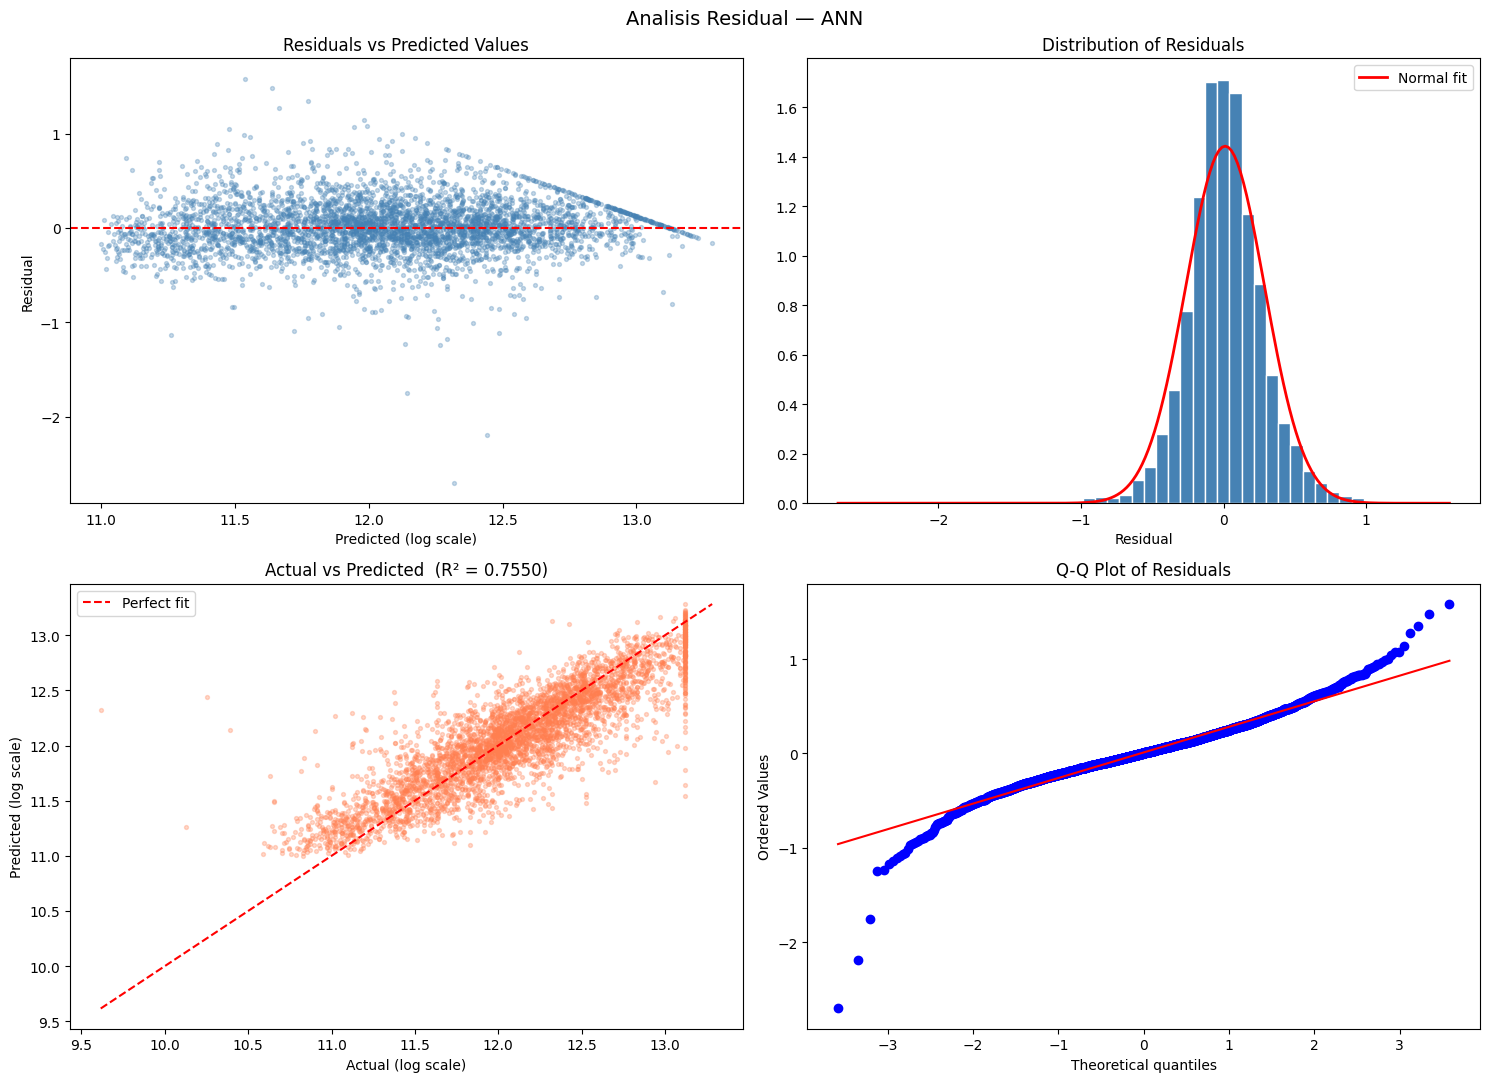

Mean residual  : 0.010390  (ideal: ~0)
Std residual   : 0.2765


In [40]:
# ── Residual plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Residuals vs Predicted
axes[0][0].scatter(y_pred, residuals, alpha=0.3, s=8, color='steelblue')
axes[0][0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0][0].set_title('Residuals vs Predicted Values')
axes[0][0].set_xlabel('Predicted (log scale)')
axes[0][0].set_ylabel('Residual')

# 2. Distribution of residuals
axes[0][1].hist(residuals, bins=50, color='steelblue', edgecolor='white', density=True)
mu, std = residuals.mean(), residuals.std()
x_range = np.linspace(residuals.min(), residuals.max(), 200)
axes[0][1].plot(x_range, stats.norm.pdf(x_range, mu, std), 'r-', linewidth=2, label='Normal fit')
axes[0][1].set_title('Distribution of Residuals')
axes[0][1].set_xlabel('Residual')
axes[0][1].legend()

# 3. Actual vs Predicted
axes[1][0].scatter(y_test, y_pred, alpha=0.3, s=8, color='coral')
min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[1][0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
axes[1][0].set_title(f'Actual vs Predicted  (R² = {r2_ann:.4f})')
axes[1][0].set_xlabel('Actual (log scale)')
axes[1][0].set_ylabel('Predicted (log scale)')
axes[1][0].legend()

# 4. Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1][1])
axes[1][1].set_title('Q-Q Plot of Residuals')

plt.suptitle('Analisis Residual — ANN', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Mean residual  : {residuals.mean():.6f}  (ideal: ~0)")
print(f"Std residual   : {residuals.std():.4f}")

# Metrics and Score

In [41]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,mean_squared_log_error

y_pred = model.predict(x_test)
print("mae :", mean_absolute_error(y_test,y_pred))
print("mse :", mean_squared_error(y_test,y_pred))
print("mae :", mean_squared_log_error(y_test,y_pred))
print("score :", r2_score(y_test,y_pred))

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
mae : 0.2024758219781617
mse : 0.07653522042066524
mae : 0.0004550237923661112
score : 0.7550335315582059


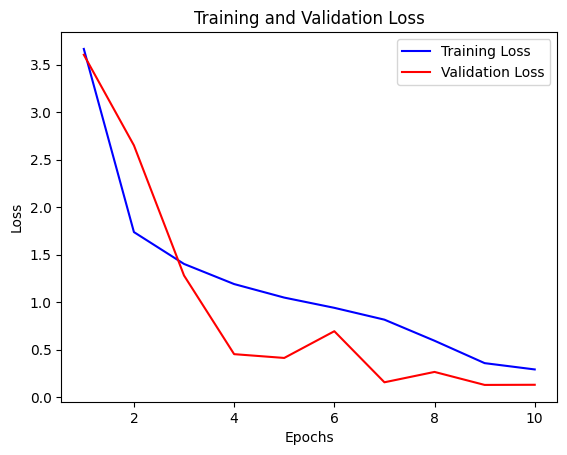

In [42]:
# Get the training and validation loss from the history object
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(training_loss) + 1)  # Fixed: was 'train_loss'

# Plot the training and validation loss
plt.plot(epochs, training_loss, 'b', label='Training Loss')
plt.plot(epochs, validation_loss, 'r', label='Validation Loss')

# Label the plot
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()


511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


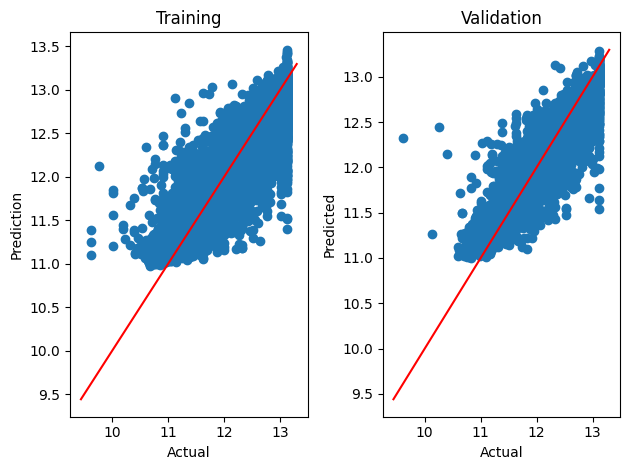

In [43]:
# Specify the dimensions
fig, axes = plt.subplots(1,2)

# This makes the individual subplots
# Training Results
axes[0].scatter(x=y_train, y=model.predict(x_train))
axes[0].set_xlabel('Actual', fontsize=10)
axes[0].set_ylabel('Prediction', fontsize=10)
axes[0].set_title('Training')

# Add 45 deg line
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')

# Validation Results
axes[1].scatter(x=y_test, y=model.predict(x_test))
axes[1].set_xlabel('Actual', fontsize=10)
axes[1].set_ylabel('Predicted', fontsize=10)
axes[1].set_title('Validation')

# add 45 deg line
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# Tight layout
fig.tight_layout()
plt.show()


# Predictive System

In [46]:
def pred(longitude, latitude, housing_median_age, total_rooms, total_bedrooms,
         population, households, median_income, ocean_proximity,
         rooms_per_household, bedrooms_per_room, population_per_household):
    features = np.array([longitude, latitude, housing_median_age, total_rooms,
                         total_bedrooms, population, households, median_income,
                         ocean_proximity, rooms_per_household, bedrooms_per_room,
                         population_per_household])
    # Fixed: use transform (not fit_transform) to avoid resetting the scaler
    features_scaled = min_max_scaler.transform([features])
    results = model.predict(features_scaled).reshape(1, -1)
    return results[0]

In [47]:
longitude = -122.2300
latitude  = 37.8800
housing_median_age  = 41.0000
total_rooms        = 880.0000
total_bedrooms   =  129.0000
population     = 322.0000
households          =    126.0000
median_income       =      8.3252
ocean_proximity       =     3.0000

# Calculate the engineered features based on the input values
rooms_per_household = total_rooms / households
bedrooms_per_room = total_bedrooms / total_rooms
population_per_household = population / households

price = pred(longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,
             rooms_per_household, bedrooms_per_room, population_per_household)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [48]:
price #  452600.0000 # actual value

array([13.06267], dtype=float32)

# Save model

In [49]:
model.save("model_ann.h5")

import pickle
pickle.dump(min_max_scaler,open('scaler.pkl','wb'))

In [50]:
from google.colab import files
files.download('model_ann.h5')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Check version and install the same in pycharm (in production)

In [51]:
import sklearn
import tensorflow as tf
import keras

print("scikit-learn version:", sklearn.__version__)
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


scikit-learn version: 1.6.1
TensorFlow version: 2.19.0
Keras version: 3.13.2
